# Indie Games Business Insight
Tujuan : Menganalisis data bisnis indie game.

## 1.Data Overview

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("indie_game_data.csv")

df.head()

,game_id,dev_cost,market_cost,price_tag,player_base,review_score,avg_playtime,is_profitable
0,ID_001,143635.03,95317.86,14.99,167473,73.1,4.9,1
1,ID_002,133427.15,18572.35,14.99,34177,47.9,8.2,1
2,ID_003,181189.11,46034.78,0.00,94072,45.1,39.0,0
3,ID_004,72651.61,63746.67,19.99,104202,55.7,24.7,1
4,ID_005,66262.90,95144.13,19.99,152389,18.6,10.0,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   game_id        500 non-null    object 
 1   dev_cost       500 non-null    float64
 2   market_cost    500 non-null    float64
 3   price_tag      500 non-null    float64
 4   player_base    500 non-null    int64  
 5   review_score   500 non-null    float64
 6   avg_playtime   500 non-null    float64
 7   is_profitable  500 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 31.4+ KB


In [15]:
df.tail()

,game_id,dev_cost,market_cost,price_tag,player_base,review_score,avg_playtime,is_profitable
495,ID_496,200787.53,69840.58,19.99,116637,72.9,26.8,1
496,ID_497,112770.03,66790.40,29.99,95406,53.2,29.6,1
497,ID_498,169632.09,93241.66,0.00,189519,53.0,11.1,0
498,ID_499,207843.83,45507.84,19.99,82108,95.5,32.4,1
499,ID_500,251494.73,61241.60,19.99,101666,100.0,4.5,1


In [16]:
df.isnull().sum()

game_id          0
dev_cost         0
market_cost      0
price_tag        0
player_base      0
review_score     0
avg_playtime     0
is_profitable    0
dtype: int64

## 2. Materi : The Honest Explorer

In [17]:
# MEAN
avg_of_playtime = df["avg_playtime"].mean()
print("Rata-rata: ", avg_of_playtime)

Rata-rata:  47.60859999999999


Ini sedikit aneh karena jika melihat data overview, mayoritas data avg_playtime tidak menyentuh angka 40.

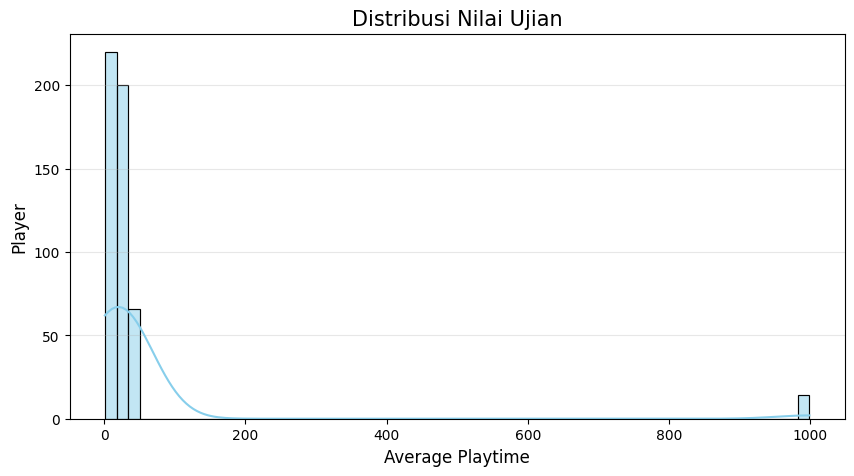

In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df["avg_playtime"], bins=60, kde=True, color="skyblue", edgecolor="black")

# 3. Kustomisasi
plt.title("Distribusi Nilai Ujian", fontsize=15)
plt.xlabel("Average Playtime", fontsize=12)
plt.ylabel("Player", fontsize=12)
plt.grid(axis='y', alpha=0.3) # Tambah garis kisi halus

plt.show()

Setelah kita visualisasi, ternyata ada semacam keanehan pada data, yaitu terdapat average playtime hingga mendekati angka 1000. Hal ini tidak masuk akal mengingat data average playtime punya format jam per minggu.

Kita coba cek dengan median.

In [19]:
# MEDIAN
median_avg_playtime = df["avg_playtime"].median()
print("Median: ", median_avg_playtime)

Median:  20.15


Kita bisa melihat angka median yang jauh lebih normal. Perbedaan hal ini disebabkan oleh adanya data anomali/aneh yang ada di dataset. Sebelumnya, dataset generator yang telah dibuat sengaja memberikan semacam glitch agar terdapat data dengan avg_playtime dengan angka yang besar. Hal ini memicu peningkatan angka rata-rata dan membuatnya tidak relevan untuk menjadi dasar analisis. Sehingga, penggunaan median jauh lebih mewakili kondisi pemain saat ini.

## 3. Materi: The Profitability Deep Dive